# Sales Prediction Using Python

## Objective

The objective of this project is to build a machine learning regression model that predicts product sales based on advertising expenditure across different media channels such as TV, Radio, and Newspaper. The project includes data analysis, visualization, model training, evaluation, and comparison of multiple regression algorithms.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [2]:
df = pd.read_csv("sales.csv")

In [3]:
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.shape

(200, 5)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales ($)                200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
df.describe()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [7]:
df.isnull().sum()

Unnamed: 0                 0
TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales ($)                  0
dtype: int64

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the dataset, identify relationships between variables, detect missing values, and gain insights before building machine learning models.

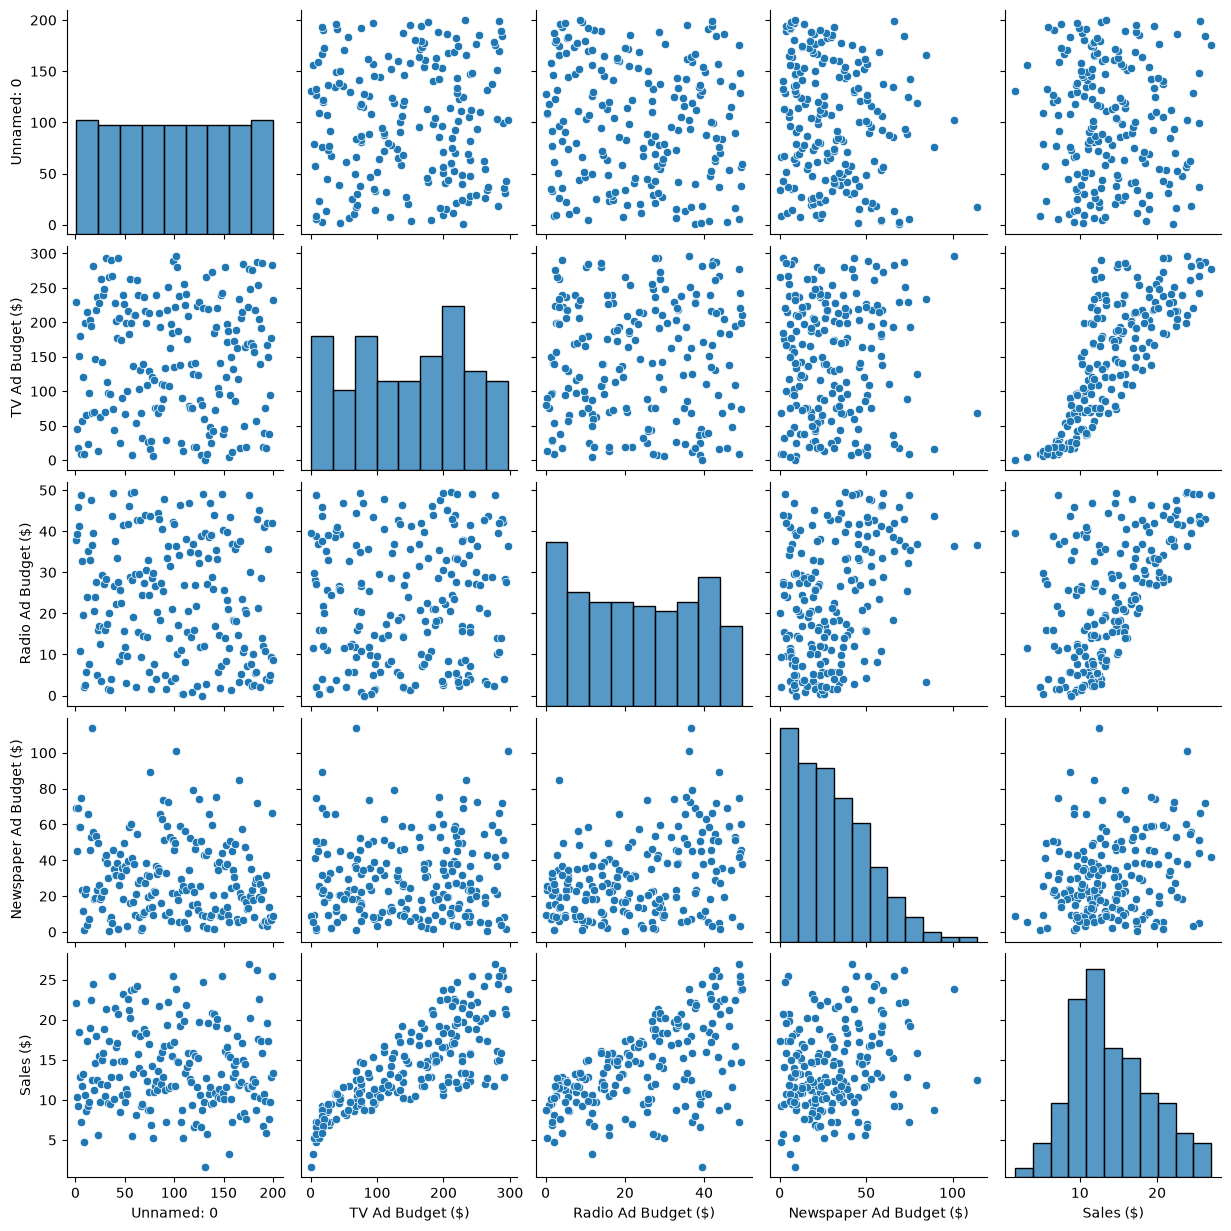

In [8]:
sns.pairplot(df)

plt.show()

## Data Cleaning

The dataset contains an additional index column (`Unnamed: 0`) that does not contribute to sales prediction. This column is removed before further analysis.

In [9]:
df = df.drop(columns=['Unnamed: 0'])

In [10]:
df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## Individual Scatter Plots

Scatter plots are used to visualize the relationship between advertising expenditure and product sales across different advertising channels.

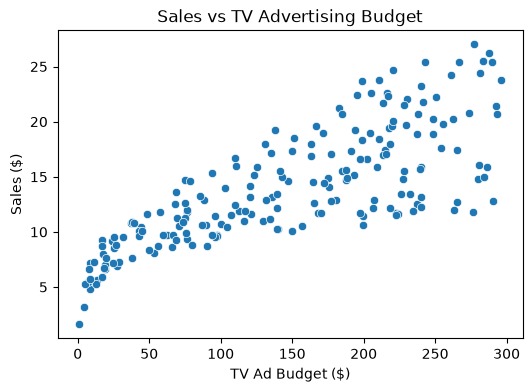

In [11]:
plt.figure(figsize=(6,4))

sns.scatterplot(x='TV Ad Budget ($)', y='Sales ($)', data=df)

plt.title("Sales vs TV Advertising Budget")

plt.show()

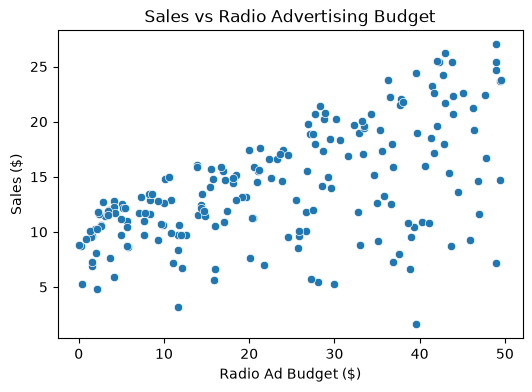

In [12]:
plt.figure(figsize=(6,4))

sns.scatterplot(x='Radio Ad Budget ($)', y='Sales ($)', data=df)

plt.title("Sales vs Radio Advertising Budget")

plt.show()

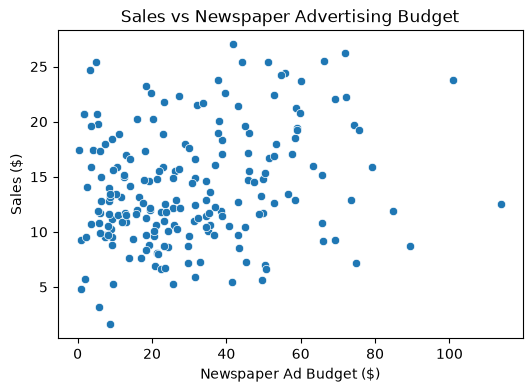

In [13]:
plt.figure(figsize=(6,4))

sns.scatterplot(x='Newspaper Ad Budget ($)', y='Sales ($)', data=df)

plt.title("Sales vs Newspaper Advertising Budget")

plt.show()

### Observation

The scatter plots show that TV advertising has the strongest positive relationship with sales, followed by Radio advertising. Newspaper advertising appears to have a weaker relationship with sales.

## Correlation Matrix

A correlation heatmap is used to measure the strength of the relationship between advertising budgets and product sales.

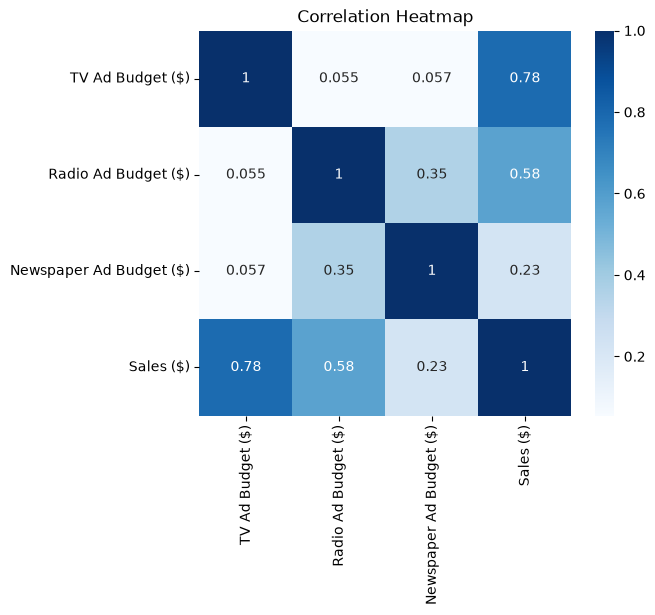

In [14]:
plt.figure(figsize=(6,5))

sns.heatmap(df.corr(), annot=True, cmap='Blues')

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap indicates that TV advertising has the strongest positive correlation with sales. Radio advertising also shows a positive correlation, while Newspaper advertising has the weakest correlation with sales.

## Train-Test Split

In [16]:
X = df.drop('Sales ($)', axis=1)

y = df['Sales ($)']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training

In [18]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_predictions = lr.predict(X_test)

In [19]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

## Model Evaluation

In [20]:
print("Linear Regression Performance")

print("MAE :", mean_absolute_error(y_test, lr_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_predictions)))
print("R² Score:", r2_score(y_test, lr_predictions))

Linear Regression Performance
MAE : 1.4607567168117603
RMSE: 1.78159966153345
R² Score: 0.899438024100912


In [21]:
print("Random Forest Performance")

print("MAE :", mean_absolute_error(y_test, rf_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_predictions)))
print("R² Score:", r2_score(y_test, rf_predictions))

Random Forest Performance
MAE : 0.6200999999999988
RMSE: 0.7685910811348248
R² Score: 0.9812843792541843


## Interpretation

Based on the feature importance analysis, TV advertising has the greatest influence on product sales, followed by Radio advertising. Newspaper advertising contributes the least to sales prediction. Therefore, businesses should prioritize TV advertising when allocating marketing budgets to maximize sales.

## Residual Plot

A residual plot is used to examine whether prediction errors are randomly distributed. Randomly scattered residuals indicate that the regression model fits the data well.

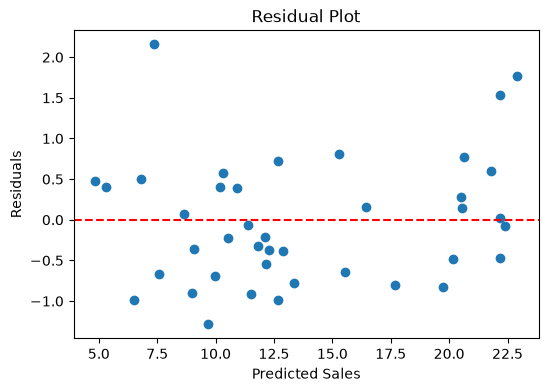

In [22]:
residuals = y_test - rf_predictions

plt.figure(figsize=(6,4))

plt.scatter(rf_predictions, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

## Feature Importance

Feature importance helps identify which advertising channel contributes the most to predicting product sales.

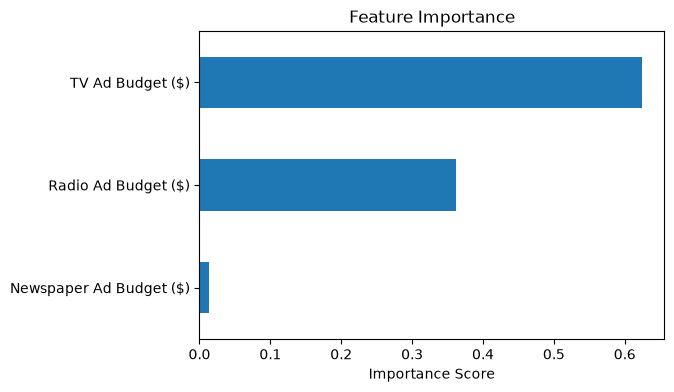

In [23]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(6,4)
)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.show()

## Interpretation

Based on the feature importance values, the advertising channel with the highest importance has the greatest influence on product sales. This information can help businesses allocate their advertising budget more effectively.

# Conclusion

In this project, machine learning regression models were developed to predict product sales using advertising expenditure on TV, Radio, and Newspaper. Exploratory Data Analysis was performed to understand the relationships between advertising channels and sales. Linear Regression and Random Forest Regressor were trained and evaluated using MAE, RMSE, and R² Score. The best-performing model demonstrated strong predictive capability, while feature importance analysis identified the most influential advertising channel for sales prediction.